# Projet Puls_Events

In [ ]:
# Récupération des données par API

# Récupération des agendas concernés par la région Bretagne via l'API OpenAgenda
import os

import pandas as pd
import requests
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.environ["OPENAGENDA_API_KEY"]
load_dotenv()

url = "https://api.openagenda.com/v2/agendas"

params = {
    "search": "Bretagne",
    "official": 1,
    "size": 100,
    "if[]": ["uid", "title", "description", "slug"],
}

headers = {
    "key": API_KEY,
}

response = requests.get(url, params=params, headers=headers, timeout=30)
response.raise_for_status()

agendas = response.json()["agendas"]
df_agendas = pd.DataFrame(agendas)

display(df_agendas)



,uid,image,description,official,title,slug
0,94909571,https://img.openagenda.com/main/9b081701820540...,Les dates à ne pas ratées des événements organ...,True,7 Technopoles Bretagne,7-technopoles-bretagne
1,4907315,https://img.openagenda.com/main/70157ec62d5f44...,La 43e édition des Journées européennes du pat...,True,Journées européennes du patrimoine 2026 - Bret...,jep-2026-bretagne
2,81060684,https://img.openagenda.com/main/6abce16e1a2e45...,La 15e édition se tiendra du 12 au 21 mai 2023.,True,Fête de la Bretagne / Gouel Breizh 2023,fete-de-la-bretagne-2023
3,91509926,https://img.openagenda.com/main/067d90b6e47243...,Agenda global Infojeunes Bretagne,True,CRIJ Bretagne,crij-bretagne
4,82540281,https://img.openagenda.com/main/685cb9c0ecec4c...,"Pôle Étudiant pour l'Innovation, le Transfert ...",True,Pépite Bretagne,pepite-bretagne
...,...,...,...,...,...,...
95,47182716,https://img.openagenda.com/main/e7b2ed664b4e4d...,Tous les évènements se déroulant dans les vill...,True,Les Plus Beaux Détours de France,plusbeauxdetours
96,48263856,https://img.openagenda.com/main/cb155b73216b47...,La French tech Alpes regroupe les écosystèmes ...,True,La French Tech Alpes,french-tech-alpes
97,48357245,https://img.openagenda.com/main/680ab62de7724f...,Retrouvez tous les AAP et concours start-up au...,True,Les appels à projets et concours #startup #ent...,aapstartup
98,49041995,https://img.openagenda.com/main/3934b8874f6745...,Association d'éducation populaire qui anime le...,True,3 Regards Léo Lagrange,3-regards-leo-lagrange


In [26]:
# Récupération des événements pour chaque agenda

import time
import json
import numpy as np

load_dotenv()


def recuperer_evenements_agenda(agenda_uid):
    url = f"https://api.openagenda.com/v2/agendas/{agenda_uid}/events"

    params_base = {
        "relative[]": ["current", "upcoming"],
        "timings[gte]": "2026-08-01T00:00:00.000+02:00",
        "monolingual": "fr",
        "detailed": 1,
        "size": 300,
        "sort": "timings.asc",
    }

    evenements = []
    after = None

    while True:
        params = params_base.copy()

        if after is not None:
            params["after[]"] = after

        response = requests.get(
            url,
            headers=headers,
            params=params,
            timeout=30,
        )
        response.raise_for_status()

        resultat = response.json()
        evenements.extend(resultat["events"])

        after = resultat.get("after")
        if after is None:
            break

    return evenements


tous_evenements = []

for agenda in df_agendas.itertuples(index=False):
    agenda_uid = agenda.uid
    evenements = recuperer_evenements_agenda(agenda_uid)

    # Conserve la provenance de chaque événement.
    for evenement in evenements:
        evenement["agenda_uid_source"] = agenda_uid
        evenement["agenda_titre_source"] = agenda.title

    tous_evenements.extend(evenements)

    # Évite d'enchaîner les appels trop vite.
    time.sleep(0.1)

df_filtre_api = pd.json_normalize(tous_evenements)

# Normalisation explicite du type après l'aplatissement JSON
def est_booleen_compatible(valeur):
    if isinstance(valeur, (bool, np.bool_)):
        return True

    if isinstance(valeur, (int, float, np.integer, np.floating)):
        return valeur in (0, 1)

    if isinstance(valeur, str):
        return valeur.strip().lower() in {
            "true", "false", "1", "0", "oui", "non"
        }

    return False


def convertir_en_booleen(valeur):
    if valeur is None or (isinstance(valeur, float) and np.isnan(valeur)):
        return pd.NA

    if isinstance(valeur, str):
        valeur = valeur.strip().lower()

    return valeur in (True, 1, 1.0, "true", "1", "oui")


colonnes_booleennes = []

for colonne in df_filtre_api.columns:
    valeurs = df_filtre_api[colonne].dropna()

    if not valeurs.empty and valeurs.map(est_booleen_compatible).all():
        df_filtre_api[colonne] = (
            df_filtre_api[colonne]
            .map(convertir_en_booleen)
            .astype("boolean")
        )
        colonnes_booleennes.append(colonne)

print("Colonnes converties en booléen :", colonnes_booleennes)

# La colonne registration mélange des booléeens et du texte, donc on la convertit en chaîne de caractères pour éviter les erreurs de type.
df_filtre_api["registration"] = (
    df_filtre_api["registration"]
    .astype("string")
)

# La colonne tags mélange des structures json et des valeurs simples
def serialiser_json(valeur):
    if valeur is None or valeur is pd.NA:
        return pd.NA

    if isinstance(valeur, float) and np.isnan(valeur):
        return pd.NA

    if isinstance(valeur, (dict, list, tuple)):
        return json.dumps(valeur, ensure_ascii=False, default=str)

    return str(valeur)


colonnes_json = []

for colonne in df_filtre_api.columns:
    valeurs = df_filtre_api[colonne].dropna()

    contient_structure = valeurs.map(
        lambda valeur: isinstance(valeur, (dict, list, tuple))
    ).any()

    if contient_structure:
        df_filtre_api[colonne] = (
            df_filtre_api[colonne]
            .map(serialiser_json)
            .astype("string")
        )
        colonnes_json.append(colonne)

print("Colonnes converties en JSON texte :", colonnes_json)

df_filtre_api.to_parquet(
    "data/parquet_sortie/evenements_culturels_filtre.parquet",
    index=False,
)

print(f"{len(df_filtre_api)} événements récupérés")
print(f"{df_filtre_api['agenda_uid_source'].nunique()} agendas interrogés")

Colonnes converties en booléen : ['featured', 'private', 'valid', 'draft', 'accessibility.ii', 'accessibility.hi', 'accessibility.vi', 'accessibility.pi', 'accessibility.mi', 'originAgenda.private', 'originAgenda.official', 'location.state', 'jaccepte-que-limage-puisse-etre-librement-utilisee-a-la-condition', 'reserve-a-la-communaute-universitaire', 'musique-du-monde', 'nm-ignorer-heure-debut', 'nm-gratuit', 'nm-ignorer-heure-fin', 'nm-carte-blanche', 'horaires-non-communiques', 'evenement-recurrent']
Colonnes converties en JSON texte : ['keywords', 'timings', 'links', 'sourceAgendas', 'extIds', 'image.variants', 'location.disqualifiedDuplicates', 'location.duplicateCandidates', 'location.links', 'location.tags', 'location.extIds', 'conditions-de-participation', 'theme-jep', 'type-de-public', 'specificites', 'location.protections-appellation-et-labels', 'location.types-de-lieu', 'thematiques-info-jeunes', 'type-devenement', 'type_devenements', 'element-patrimoine-culturel-immateriel', 

In [ ]:
# Récupération des données par download direct

import pandas as pd

# Chargement des sources
fichier_source = "Data/evenements-publics-openagenda.csv"


for bloc in pd.read_csv(
    fichier_source,
    sep=";",
    chunksize=10_000,
    encoding="utf-8"
):
    display(bloc.head())
    print(bloc.columns.tolist())
    break



,Identifiant,Slug,URL canonique,Titre,Description,Description longue,Détail des conditions,Mots clés,Image,Crédits image,...,Agenda d'origine (uid),Contributeur: Email,Contributeur: Téléphone,Contributeur: Nom,Contributeur: Fonction,Contributeur: organisation,Catégorie,Nom du pays,Registration,Liens additionnels
0,12413663,centre-social-st-rambert-dalbon-5148959,https://openagenda.com/tootsweet/events/centre...,Centre social St Rambert d'Albon,organisé par Centre social St Rambert d'Albon,"<p>Atelier de danses ""Folk""</p>\n<p></p>\n<p>A...",Gratuit,"breton,bretone,danse,atelier,26",NaN,NaN,...,82566953.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,75551745,coupe-de-normandie-vtt-25-septembre-2021,https://openagenda.com/tootsweet/events/coupe-...,Coupe de Normandie VTT - 25 septembre 2021 - F...,Coupe de Normandie et Trophée Régional des Jeu...,<p>L'association Vélo Jeunes Aventure organise...,pass sanitaire obligatoire,"sport,vtt,feuguerolles bully,calvados",https://cibul.s3.amazonaws.com/60a782a88d1e433...,NaN,...,94552197.0,NaN,NaN,NaN,NaN,NaN,NaN,France (Métropole),"[{""type"": ""link"", ""value"": ""http://www.normand...",NaN
2,87153658,un-deux-trad-invite-les-tralala-lovers-8266071,https://openagenda.com/tootsweet/events/un-deu...,"Un, deux, trad invite les Tralala Lovers",avec Tralala Lovers et Viendez-Voir,"<p>Le ""fameux"" bal de Mirecourt est enfin de r...",10€,"baltrad,balfolk,danse,chant,musique,88",https://cibul.s3.amazonaws.com/07ad84a33c24458...,NaN,...,82566953.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[{""data"": {""author_url"": ""https://www.youtube...."
3,35021962,totalement-90-6588587,https://openagenda.com/tootsweet/events/totale...,Totalement 90,"WORLDS APART, LARUSSO, INDRA, BORIS, YANNICK E...",<p>Totalement 90 accueillera le chanteur Boris...,Tarifs: de 35€ à 45€,"chanson,spectacle,show,Longjumeau,Essonne,Ile ...",https://cibul.s3.amazonaws.com/9f486cc452114f1...,NaN,...,15004001.0,NaN,NaN,NaN,NaN,NaN,NaN,France (Métropole),"[{""type"": ""phone"", ""value"": ""01 69 09 09 09""}]",NaN
4,71691788,atelier-signer-avec-bebe-avec-laure-giry,https://openagenda.com/issy-com/events/atelier...,Atelier « Signer avec bébé » avec Laure Giry,"Séance N°1 sur 2, pour découvrir la communicat...",NaN,Sur réservation auprès d’A3N,"signer,bébé,gestuelle bébé,communication avec ...",https://cibul.s3.amazonaws.com/event_atelier-s...,NaN,...,80515007.0,NaN,NaN,NaN,NaN,NaN,NaN,France (Métropole),"[{""type"": ""phone"", ""value"": ""06 81 91 43 44""},...",NaN


['Identifiant', 'Slug', 'URL canonique', 'Titre', 'Description', 'Description longue', 'Détail des conditions', 'Mots clés', 'Image', 'Crédits image', 'Aperçu', 'Image source', 'Dernière mise à jour', 'Résumé horaires', 'Première date - Début', 'Première date - Fin', 'Dernière date - Début', 'Dernière date - Fin', 'Horaires détaillés', "Code d'accessibilité", 'Accessibilité', 'Identifiant du lieu', 'Coordonnées géographiques', 'Nom du lieu', 'Adresse', 'Arrondissement', 'Code INSEE', 'Code postal', 'Ville', 'Département', 'Région', 'Pays', 'Image du lieu', "Crédits de l'image du lieu", 'Téléphone du lieu', 'Site web du lieu', 'Liens du lieu', 'Tags du lieu', 'Description du lieu', 'Accès / Itinéraire', 'Événement physique ou en ligne', "Lien d'accès en ligne", "État de l'événement", 'Age minimum', 'Age maximum', "Agenda d'origine (titre)", "Agenda d'origine (uid)", 'Contributeur: Email', 'Contributeur: Téléphone', 'Contributeur: Nom', 'Contributeur: Fonction', 'Contributeur: organisati

In [2]:
# conversion en fichiers parquet
for i, bloc in enumerate(pd.read_csv(fichier_source,  sep=";", chunksize=100_000)):
    bloc.to_parquet(f"data/parquet_sortie/part-{i:04d}.parquet", index=False)

In [ ]:
# Analyse du fichier parquet
df = pd.read_parquet("data/parquet_sortie/part-0000.parquet")
df.describe()

,uid,state,attendanceMode,creatorUid,ownerUid,status,agenda_uid_source,originAgenda.locationSetUid,originAgenda.uid,image.size.width,...,genre,evenement,equipement,discipline,categorie,email-de-contact,types-devenements,location.access,thematiques,la-french-tech-organise-ou-coorganise-levenement
count,9.365000e+03,9365.0,9365.000000,9.365000e+03,9.365000e+03,9365.00000,9.365000e+03,1.194000e+03,9.364000e+03,9206.000000,...,11.000000,17.000000,128.000000,22.0,194.000000,0.0,446.000000,0.0,24.000000,24.0
mean,5.037958e+07,2.0,1.028724,1.480274e+13,1.477269e+13,1.00897,1.368195e+07,5.182413e+07,2.381355e+07,687.561156,...,2.454545,5.588235,2.398438,4.0,2.804124,NaN,10.589686,NaN,6.666667,9.0
std,2.874617e+07,0.0,0.223863,4.948324e+13,4.947798e+13,0.19257,1.449343e+07,3.569648e+07,2.889428e+07,53.427231,...,0.934199,3.083400,2.594178,0.0,5.060544,NaN,8.117662,NaN,1.203859,0.0
min,1.392300e+04,2.0,1.000000,2.383000e+03,2.383000e+03,1.00000,6.269500e+04,5.917000e+04,5.462100e+04,76.000000,...,1.000000,1.000000,1.000000,4.0,1.000000,NaN,1.000000,NaN,4.000000,9.0
25%,2.581707e+07,2.0,1.000000,2.532862e+07,2.532862e+07,1.00000,3.215990e+06,1.153868e+07,3.215990e+06,700.000000,...,2.000000,2.000000,1.000000,4.0,1.000000,NaN,3.000000,NaN,6.000000,9.0
50%,5.070817e+07,2.0,1.000000,5.738026e+07,5.738026e+07,1.00000,4.907315e+06,5.849845e+07,4.907315e+06,700.000000,...,3.000000,8.000000,1.000000,4.0,1.000000,NaN,15.000000,NaN,6.500000,9.0
75%,7.522014e+07,2.0,1.000000,8.387768e+07,8.387768e+07,1.00000,2.050002e+07,9.468260e+07,3.849588e+07,700.000000,...,3.000000,8.000000,4.000000,4.0,1.000000,NaN,17.000000,NaN,8.000000,9.0
max,9.999938e+07,2.0,3.000000,2.813558e+14,2.813558e+14,6.00000,9.490957e+07,9.917817e+07,9.989620e+07,700.000000,...,3.000000,8.000000,12.000000,4.0,18.000000,NaN,24.000000,NaN,8.000000,9.0


In [5]:
# Filtre sur la région et la date

#print(bloc.columns.tolist())
df_filtre = df[
    (df["Région"] == "Bretagne") &
    (df["Dernière date - Début"] >= "2025-08-01")
].copy()

df_filtre.to_parquet("data/parquet_sortie/part-0000-filtre.parquet", index=False)

# Suppression des identifiants
df_filtre = df_filtre.drop(columns=[df_filtre.columns[0], df_filtre.columns[21]]).copy()

df_filtre.head()
df_filtre.info()

<class 'pandas.DataFrame'>
Index: 1050 entries, 2130 to 98848
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Slug                            1050 non-null   str    
 1   URL canonique                   1050 non-null   str    
 2   Titre                           1039 non-null   str    
 3   Description                     1039 non-null   str    
 4   Description longue              936 non-null    str    
 5   Détail des conditions           625 non-null    str    
 6   Mots clés                       520 non-null    str    
 7   Image                           968 non-null    str    
 8   Crédits image                   558 non-null    str    
 9   Aperçu                          968 non-null    str    
 10  Image source                    968 non-null    str    
 11  Dernière mise à jour            1050 non-null   str    
 12  Résumé horaires                 1050 non-null 

# Reprise du traitement sur le df issu de l'API

In [30]:
print(df_filtre_api.dtypes)

longDescription                                         str
country                                                 str
featured                                            boolean
private                                             boolean
keywords                                             string
                                                     ...   
thematiques                                         float64
la-french-tech-organise-ou-coorganise-levenement    float64
tag-group                                            string
uid-externe                                             str
acces-en-transports                                     str
Length: 184, dtype: object


In [31]:
df_filtre_api.count()

longDescription                                     9016
country                                             9344
featured                                            9365
private                                             9365
keywords                                            3738
                                                    ... 
thematiques                                           24
la-french-tech-organise-ou-coorganise-levenement      24
tag-group                                              2
uid-externe                                           33
acces-en-transports                                    1
Length: 184, dtype: int64

In [36]:
# Tests unitaires
df_test = pd.read_parquet("data/parquet_sortie/evenements_culturels_filtre.parquet")
print(df_test.head())
print(df_test.shape)
print("Régions filtrées : "+ df_test["Région"].unique())

# Vérification : True si toutes les dates respectent la condition
controle = (df_test["Dernière date - Début"] >= "2025-08-01").all()
print("Contrôle de date : "+ str(controle))

                                     longDescription             country  \
0  Vous êtes étudiant.e ou jeune diplômé.e, intér...  France (Métropole)   
1  Venez découvrir Fabrik ta pépite lors de la so...  France (Métropole)   
2  Vous êtes étudiant.e ou jeune diplômé.e, intér...  France (Métropole)   
3  Venez découvrir Fabrik ta pépite lors de la so...  France (Métropole)   
4  Au programme  \n**1\. Comprendre les enjeux de...  France (Métropole)   

   featured  private                                           keywords  \
0     False    False  ["entrepreneuriat", "étudiant", "création d'ac...   
1     False    False                                               <NA>   
2     False    False  ["entrepreneuriat", "étudiant", "création d'ac...   
3     False    False                                               <NA>   
4     False    False  ["reseaux", "networking", "vannes", "transmiss...   

                    dateRange      timezone     imageCredits  \
0    Jeudi 3 septembre, 12h0

KeyError: 'Région'

In [37]:
# Nettoyage des données
def valeurs_manquantes(serie):
    if pd.api.types.is_string_dtype(serie) or serie.dtype == "object":
        return serie.isna() | serie.astype("string").str.strip().eq("")
    return serie.isna()

rapport_colonnes = pd.DataFrame({
    "type": df_filtre.dtypes.astype(str),
    "valeurs_manquantes": {
        colonne: valeurs_manquantes(df_filtre_api[colonne]).sum()
        for colonne in df_filtre.columns
    },
})

rapport_colonnes["taux_remplissage"] = (
    1 - rapport_colonnes["valeurs_manquantes"] / len(df_filtre_api)
).round(3)

rapport_colonnes = rapport_colonnes.sort_values("taux_remplissage")

display(rapport_colonnes)


,type,valeurs_manquantes,taux_remplissage
motive,object,9365,0.0
image,float64,9365,0.0
image.extension,float64,9365,0.0
type_devenements,object,9363,0.0
image.originalName,float64,9365,0.0
...,...,...,...
originAgenda.title,str,1,1.0
originAgenda.official,object,1,1.0
accessibility.vi,bool,0,1.0
accessibility.hi,bool,0,1.0


In [38]:
colonnes_peu_remplies = rapport_colonnes.query(
    "taux_remplissage < 0.10"
)

display(colonnes_peu_remplies)

,type,valeurs_manquantes,taux_remplissage
motive,object,9365,0.000
image,float64,9365,0.000
image.extension,float64,9365,0.000
type_devenements,object,9363,0.000
image.originalName,float64,9365,0.000
...,...,...,...
tarifs-conditions-de-paticpation,object,8919,0.048
location.types-de-lieu,object,8819,0.058
categories,object,8805,0.060
extIds,object,8670,0.074


In [44]:
seuil_remplissage = 0.10

colonnes_a_supprimer = rapport_colonnes.index[
    rapport_colonnes["taux_remplissage"] < seuil_remplissage
].tolist()

df_nettoye = (
    df_filtre_api
    .drop(columns=colonnes_a_supprimer)
    .drop_duplicates()
    .copy()
)

# Nettoyage des champs texte
colonnes_texte = df_nettoye.select_dtypes(
    include=["object", "string"]
).columns

for colonne in colonnes_texte:
    df_nettoye[colonne] = (
        df_nettoye[colonne]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

df_nettoye.to_parquet(
    "data/parquet_sortie/evenements_culturels_nettoye.parquet",
    index=False,
)

print("Colonnes supprimées :", colonnes_a_supprimer)
print("Dimensions après nettoyage :", df_nettoye.shape)

Colonnes supprimées : ['motive', 'image', 'image.extension', 'type_devenements', 'image.originalName', 'element-patrimoine-culturel-immateriel', 'thematique-economie', 'acces-en-transports', 'tag-group', 'conditions-tarifaires', 'email-de-contact', 'location.access', 'theme-2016', 'genre', 'campus', 'contributororganization', 'cochez-la-case-si-vous-etes-affiliees-a-lun-des-partenaires-suivants', 'tarifs-detail', 'categorie-de-produits', 'label', 'type-de-structure', 'type-devenements', 'evenement', 'conseil', 'thematiques-info-jeunes', 'thematique-patrimoine', 'diffusion-sur-le-site-info-jeunes-france', 'champ-art', 'type-de-public-vise', 'discipline', 'thematiques', 'nm-ignorer-heure-debut', 'thematique-social-societe', 'thematique', 'la-french-tech-organise-ou-coorganise-levenement', 'nm-ignorer-heure-fin', 'reserve-a-la-communaute-universitaire', 'nm-gratuit', 'nm-carte-blanche', 'nm-types', 'nm-diffusion', 'nm-thematiques', 'nm-public', 'location.mergedIn', 'thematique-environneme

# Génération des embeddings

In [41]:
import os
from pathlib import Path
import numpy as np

from dotenv import load_dotenv
from mistralai.client import Mistral

from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv(Path.cwd() / ".env")
api_key = os.environ["MISTRAL_API_KEY"]

# Colonnes utiles à la recherche sémantique
colonnes_embedding = [
   "title",
   "description",
   "longDescription",
   "keywords",
   "location.city",
   "location.region",
]

# Une ligne DataFrame devient un document texte
documents = (
    df_nettoye[colonnes_embedding]
    .fillna("")
    .astype(str)
    .apply(
        lambda ligne: "\n".join(
            f"{colonne}: {valeur.strip()}"
            for colonne, valeur in ligne.items()
            if valeur.strip()
        ),
        axis=1,
    )
)

# Chunking et traitement des documents vides
mask = documents.str.strip().ne("")
documents = documents.loc[mask]

# Découpe les documents longs avant leur vectorisation.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1_000,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks = []

for index_evenement, texte in documents.items():
    for numero_chunk, texte_chunk in enumerate(splitter.split_text(texte)):
        chunks.append({
            "index_evenement": index_evenement,
            "numero_chunk": numero_chunk,
            "texte_chunk": texte_chunk,
        })

df_embeddings = pd.DataFrame(chunks)

documents = df_embeddings["texte_chunk"].tolist()

# Appels en lots pour traiter les 1 050 événements proprement
taille_lot = 100
embeddings = []

with Mistral(api_key=api_key) as mistral:
    for debut in range(0, len(documents), taille_lot):
        lot = documents[debut:debut + taille_lot]

        reponse = mistral.embeddings.create(
            model="mistral-embed",
            inputs=lot,
        )

        embeddings.extend(
            item.embedding
            for item in sorted(
                reponse.data, 
                key=lambda item: item.index if item.index is not None else -1,)
        )

# Conserve le texte envoyé et son vecteur sur chaque événement
df_embeddings["embedding"] = embeddings

df_embeddings.to_parquet(
    "data/parquet_sortie/evenements_embeddings_mistral.parquet",
    index=False,
)

print(f"{len(df_embeddings)} embeddings créés.")
print(f"Dimension d'un embedding : {len(embeddings[0])}")

15647 embeddings créés.
Dimension d'un embedding : 1024


In [42]:
df_embeddings.head()

,index_evenement,numero_chunk,texte_chunk,embedding
0,0,0,title: Permanence Pépite Bretagne\ndescription...,"[-0.0234527587890625, 0.0193328857421875, 0.03..."
1,1,0,title: Soirée de lancement Fabrik ta pépite – ...,"[-0.0285491943359375, 0.01806640625, 0.0489196..."
2,1,1,### Pourquoi venir à la soirée de lancement ?\...,"[-0.038299560546875, 0.01241302490234375, 0.04..."
3,1,2,"Que vous veniez seul·e ou avec des ami·e·s, vo...","[-0.018707275390625, 0.0240020751953125, 0.034..."
4,2,0,title: Permanence Pépite Bretagne\ndescription...,"[-0.023468017578125, 0.01934814453125, 0.03836..."


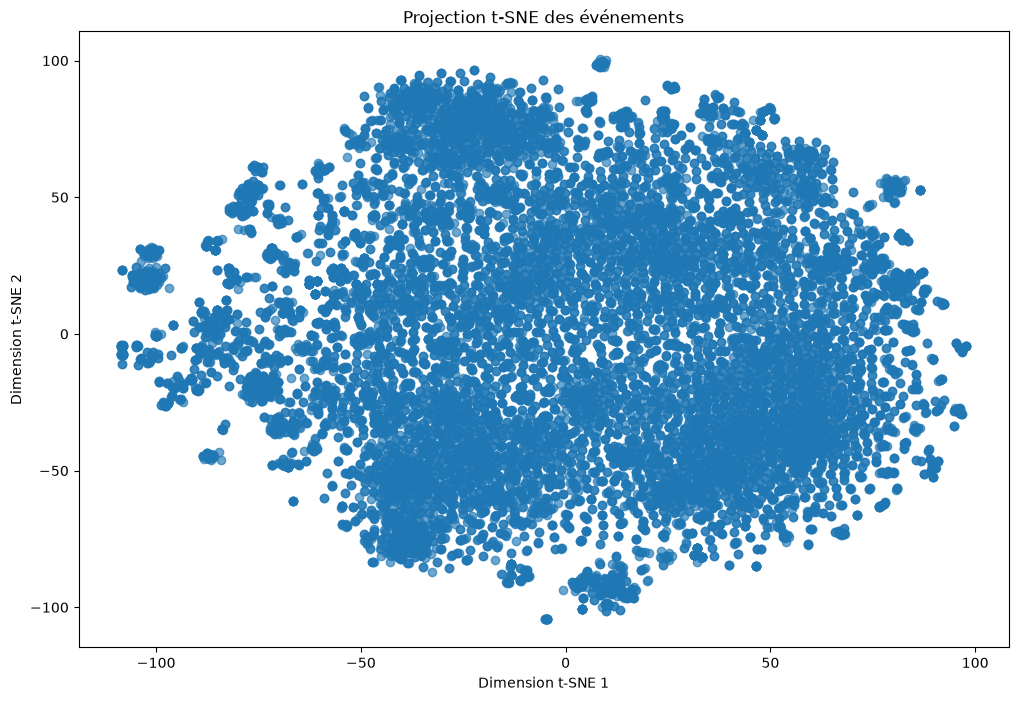

In [43]:
# Réduction de dimension pour les embeddings Mistral

# Conversion de la colonne contenant les vecteurs Mistral en matrice NumPy
matrice_embeddings = np.asarray(df_embeddings["embedding"].tolist())

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1_000,
    random_state=42,
)

embeddings_2d = tsne.fit_transform(matrice_embeddings)

df_embeddings["tsne_x"] = embeddings_2d[:, 0]
df_embeddings["tsne_y"] = embeddings_2d[:, 1]

plt.figure(figsize=(12, 8))
plt.scatter(
    df_embeddings["tsne_x"],
    df_embeddings["tsne_y"],
    alpha=0.65,
)

plt.title("Projection t-SNE des événements")
plt.xlabel("Dimension t-SNE 1")
plt.ylabel("Dimension t-SNE 2")
plt.show()